In [57]:
%pip install scikit-fda

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/582.2 kB ? eta -:--:--
   --------------------------------------- 582.2/582.2 kB 20.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 52.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 53.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 36.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -------------- ------------------------- 14.2/38.1 MB 74.3 MB/s eta 0:00:01
   ----------------------------- ---------- 28.0/38.1 MB 71.2 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 63.9 MB/s eta 0:00:00
Note: you may need to rest


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\anruk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import zipfile
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf
import math
import skfda
from skfda.representation.grid import FDataGrid

In [3]:
zip_file_path = 'datos_competicion.zip'
extraction_path = 'data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}'")

'datos_competicion.zip' unzipped to 'data'


In [4]:
trades = pd.read_csv('data/trades_benchmark.csv')

In [5]:
# Convert to datetime (keeps timezone correctly)
trades["timestamp_open"] = pd.to_datetime(trades["dateOpen"], format="mixed")
# Remove timezone
trades["timestamp_open"] = trades["timestamp_open"].dt.tz_convert(None)
# Drop seconds and microseconds
trades["timestamp_open"] = trades["timestamp_open"].dt.floor("min")


trades["timestamp_close"] = pd.to_datetime(trades["dateClose"], format="mixed")
# Remove timezone
trades["timestamp_close"] = trades["timestamp_close"].dt.tz_convert(None)
# Drop seconds and microseconds
trades["timestamp_close"] = trades["timestamp_close"].dt.floor("min")


In [6]:
algoritmos_path = r'data/algoritmos'

alg_bench = pd.unique(trades['productname'])
# Get a list of all files in the 'algoritmos' folder
algo_files = [f for f in os.listdir(algoritmos_path) if f.endswith('.csv')]

if algo_files:
    algs_benchmark = [os.path.join(algoritmos_path, name + ".csv") for name in alg_bench]
else:
    print(f"No CSV files found in '{algoritmos_path}'")

In [7]:
horas = set()
fecha_max = datetime(2019,12,31,0,0,0)
fecha_min = datetime(2025,12,31,0,0,0)
for algo in algs_benchmark:

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'], format = "%Y-%m-%d %H:%M:%S")
    horas.update(pd.unique(df['plot_date']))
    fecha_max_algo = df['plot_date'].max()
    fecha_min_algo = df['plot_date'].min()
    if fecha_max_algo > fecha_max:
        fecha_max = fecha_max_algo
    if fecha_min_algo< fecha_min:
        fecha_min = fecha_min_algo
horas = sorted(list(horas))

In [74]:
df_algoritmos = pd.DataFrame()
df_algoritmos['Date'] = horas

In [ ]:
import os

for algo in algs_benchmark:
    name = os.path.splitext(os.path.basename(algo))[0]

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'])

    df_merge = (
        df[['plot_date', 'open']]
        .rename(columns={'open': name})
    )

    df_algoritmos = df_algoritmos.merge(
        df_merge,
        how='left',
        left_on='Date',
        right_on='plot_date'
    ).drop(columns='plot_date')

df_algoritmos.fillna(0, inplace=True)

In [10]:
df_algoritmos.shape

(7146, 272)

In [76]:
df_algoritmos.head()

,Date,fpJbh,HcI9f,QEwOm,EFKyf,lVhDF,RsCCj,LYP1Q,yqSyy,MeTxk,...,INaLS,V7Lrn,KLCQs,eLk6n,IfdDD,uPX0V,fS7OL,bpN6K,eACAc,AmsD8
0,2020-06-01 01:00:00,0.0,0.00,0.0,214.49,0.0,207.11,0.0,0.0,133.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-06-01 05:00:00,0.0,189.54,0.0,214.90,0.0,207.17,0.0,0.0,133.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-06-01 09:00:00,0.0,189.55,0.0,214.29,0.0,207.20,0.0,0.0,133.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-06-01 13:00:00,0.0,189.61,0.0,214.21,0.0,207.05,0.0,0.0,133.77,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-06-01 17:00:00,0.0,0.00,0.0,214.83,0.0,207.15,0.0,0.0,133.60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
trades['prox_open_hour'] = '-'
trades['prox_close_hour'] = '-'
trades[['precio_open','precio_close']] = 0.0
trades['n_filas'] = 0

for index, row in trades.iterrows():
    fecha_open = row['timestamp_open']
    fecha_close = row['timestamp_close']
    try:
        closest_idx_min = (df_algoritmos["Date"] - fecha_open).abs().idxmin()
        closest_idx_max = (df_algoritmos["Date"] - fecha_close).abs().idxmin()
        n_filas = closest_idx_max - closest_idx_min + 1
    except:
        pass
    trades.loc[index, 'prox_open_hour']= df_algoritmos.loc[closest_idx_min,'Date']
    trades.loc[index, 'prox_close_hour']= df_algoritmos.loc[closest_idx_max,'Date']
    trades.loc[index,'n_filas'] = n_filas
    trades.loc[index,'precio_open'] = df_algoritmos.loc[closest_idx_min,row['productname']]
    trades.loc[index,'precio_close'] = df_algoritmos.loc[closest_idx_max,row['productname']]
trades['profit_percentage'] = trades.apply(lambda row:  (row['precio_close'] - row['precio_open'])/row['precio_open']
                                            if (row['precio_open']!=0 and row['precio_close']!=0) else 0, axis = 1)
trades['trade_length'] = (trades['timestamp_close'] - trades['timestamp_open'])/np.timedelta64(1,'D')

In [13]:
trades_finalizados = trades.loc[trades['n_filas']!=0]

In [14]:
#para hacer una evaluación del comportamiento, es importante tener unos cuantos puntos para graficar el comportamiento
#en particular, necesitamos los datos del algoritmo correspondiente para el momento de cierre. 
df_completo = trades_finalizados.loc[(pd.to_datetime(trades_finalizados['prox_close_hour']).dt.day == pd.to_datetime(trades_finalizados['timestamp_close']).dt.day)
    & trades_finalizados['profit_percentage']!=0, ['productname','prox_open_hour','prox_close_hour', 'n_filas','precio_open','precio_close','profit_percentage','trade_length']]
df_completo.reset_index(inplace=True,drop=True)

In [15]:
#necesitamos una función que normalice funciones con una gaussiana a un dominio común del intervalo [0,1]
def gaussian_kernel_smoother(x, y, x_eval, bandwidth):
    x = np.asarray(x).flatten()
    y = np.asarray(y).flatten()
    x_eval = np.asarray(x_eval).flatten()

    # Compute squared distance matrix
    diff = x_eval[:, None] - x[None, :]

    # Gaussian kernel weights
    weights = np.exp(-0.5 * (diff / bandwidth)**2)

    # Normalize weights
    weights /= np.sum(weights, axis=1, keepdims=True)

    # Smoothed values
    y_smooth = weights @ y
    return y_smooth


In [16]:
df_completo

,productname,prox_open_hour,prox_close_hour,n_filas,precio_open,precio_close,profit_percentage,trade_length
0,EFKyf,2020-06-03 17:00:00,2020-07-08 09:00:00,149,215.44,222.51,0.032817,34.725694
1,lVhDF,2020-06-03 17:00:00,2020-12-23 06:00:00,868,157.19,144.18,-0.082766,202.574306
2,RsCCj,2020-06-03 17:00:00,2020-07-23 17:00:00,217,207.65,188.86,-0.090489,49.934722
3,yqSyy,2020-06-04 17:00:00,2021-03-05 18:00:00,1165,201.27,210.92,0.047946,274.112500
4,MeTxk,2020-06-11 21:00:00,2020-07-29 13:00:00,203,134.00,136.23,0.016642,47.548611
...,...,...,...,...,...,...,...,...
2540,AmsD8,2024-12-19 14:00:00,2024-12-20 14:00:00,7,148.50,148.61,0.000741,0.999306
2541,UCc87,2024-12-19 14:00:00,2024-12-20 14:00:00,7,86.50,86.35,-0.001734,0.999306
2542,AmsD8,2024-12-24 14:00:00,2024-12-30 14:00:00,19,149.32,149.14,-0.001205,5.999306
2543,2Zc0n,2024-12-24 14:00:00,2024-12-26 14:00:00,7,129.45,129.27,-0.001390,1.999306


In [17]:
trades_coarse_functions = []
for index, row in df_completo.iterrows():
    precios = [df_algoritmos.loc[(df_algoritmos['Date']>=row['prox_open_hour']) & (df_algoritmos['Date']<=row['prox_close_hour']),row['productname']].values]
    trades_coarse_functions.append([index, np.linspace(0,1,row['n_filas']),np.array(precios)/np.array(precios).mean()])

In [19]:
x_common = np.linspace(0,1,200)
smooth_functions = []
bandwidth = 0.04
for index_i,x_i,y_i in trades_coarse_functions:
    smooth_functions.append(gaussian_kernel_smoother(x_i,y_i, x_common,bandwidth))


## Cuándo vender

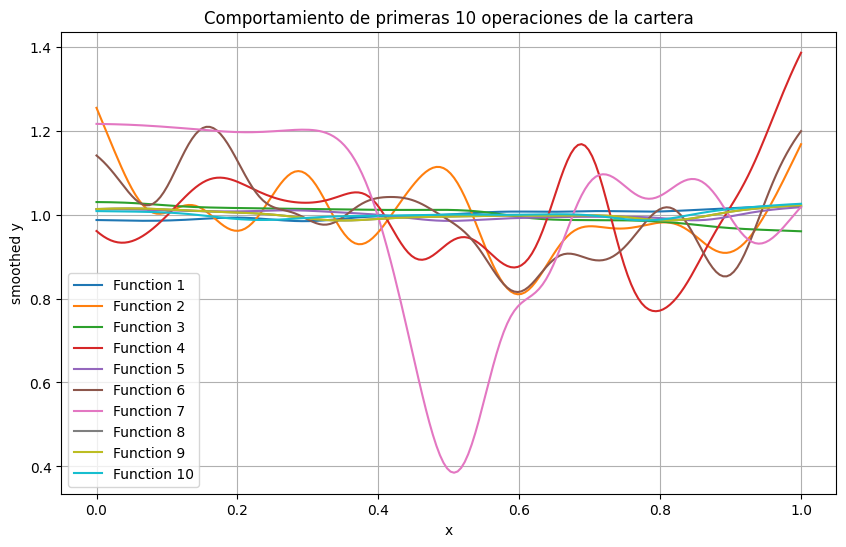

In [20]:
plt.figure(figsize=(10,6))
for i in range(10):
    plt.plot(x_common, smooth_functions[i], label=f"Function {i+1}")
plt.xlabel("x")
plt.ylabel("smoothed y")
plt.title("Comportamiento de primeras 10 operaciones de la cartera")
plt.legend()
plt.grid(True)
plt.show()

Tenemos que ver si es posible clasificar el comportamiento de los productos antes de que se adquirieran por la cartera (razones para comprar)

In [21]:
trades_history_coarse_functions = []
for index, row in df_completo.iterrows():
    precios_previos = df_algoritmos.loc[(df_algoritmos['Date']<=row['prox_open_hour']) & (df_algoritmos[row['productname']]!=0),row['productname']].values
    trades_history_coarse_functions.append([index, np.linspace(0,1,len(precios_previos[:35])),np.array(precios_previos[:35])/np.array(precios_previos[:35]).mean()])

In [22]:
history_smooth_functions = []
x_common = np.linspace(0,1,200)
andwidth = 0.04
for index_i,x_i,y_i in trades_history_coarse_functions:
    history_smooth_functions.append(gaussian_kernel_smoother(x_i,y_i, x_common,bandwidth))


## Cuándo comprar

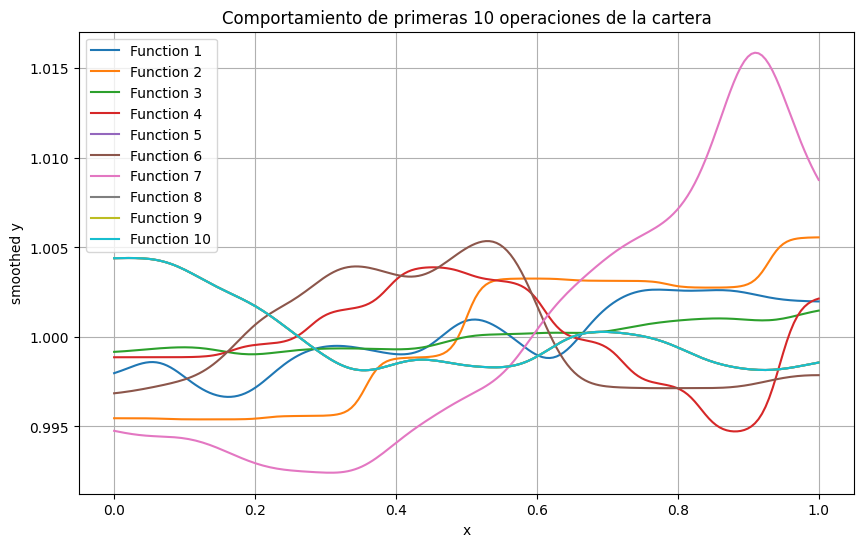

In [23]:
plt.figure(figsize=(10,6))
for i in range(10):
    plt.plot(x_common, history_smooth_functions[i], label=f"Function {i+1}")
plt.xlabel("x")
plt.ylabel("smoothed y")
plt.title("Comportamiento de primeras 10 operaciones de la cartera")
plt.legend()
plt.grid(True)
plt.show()

## Sin normalizar:

In [24]:
trades_coarse_functions = []

for index, row in df_completo.iterrows():
    mask = (
        (df_algoritmos['Date'] >= row['prox_open_hour']) &
        (df_algoritmos['Date'] <= row['prox_close_hour'])
    )

    df_slice = df_algoritmos.loc[mask]

    if df_slice.empty:
        continue

    x_real = np.arange(len(df_slice))                     # eje x REAL (barras)
    y_real = df_slice[row['productname']].values          # precios REALES

    trades_coarse_functions.append([index, x_real, y_real])

In [25]:
x_common = np.arange(200)   # dominio común en barras
bandwidth = 5               # ancho del kernel (en barras)

smooth_functions = []

for index_i, x_i, y_i in trades_coarse_functions:
    smooth_y = gaussian_kernel_smoother(x_i, y_i, x_common, bandwidth)
    smooth_functions.append(smooth_y)

C:\Users\anruk\AppData\Local\Temp\ipykernel_23840\147921865.py:14: RuntimeWarning: invalid value encountered in divide
  weights /= np.sum(weights, axis=1, keepdims=True)


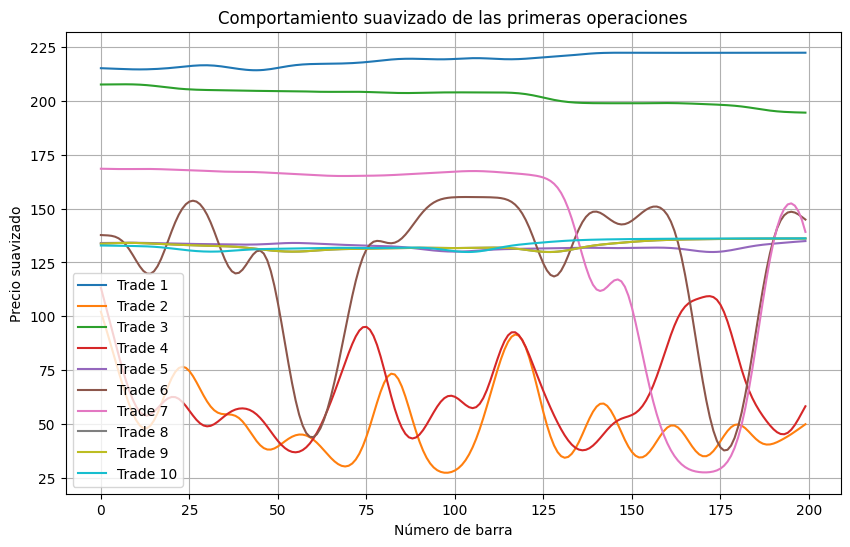

In [26]:
plt.figure(figsize=(10,6))

for i in range(min(10, len(smooth_functions))):
    plt.plot(x_common, smooth_functions[i], label=f"Trade {i+1}")

plt.xlabel("Número de barra")
plt.ylabel("Precio suavizado")
plt.title("Comportamiento suavizado de las primeras operaciones")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
trades

,volume,dateOpen,dateClose,total_invested_amount_EOD,equity_EOD,AUM,equity_normalized,productname,timestamp_open,timestamp_close,prox_open_hour,prox_close_hour,precio_open,precio_close,n_filas,profit_percentage,trade_length
0,8000.0,2020-06-03 17:06:19.822000+00:00,2020-06-05 12:41:58.325000+00:00,91600.00,1.301140e+04,1.301140e+05,1.308571e+05,fpJbh,2020-06-03 17:06:00,2020-06-05 12:41:00,2020-06-03 17:00:00,2020-06-05 13:00:00,0.00,90.54,12,0.000000,1.815972
1,8000.0,2020-06-03 17:06:19.822000+00:00,2020-06-12 17:40:04.988000+00:00,106500.00,1.252361e+04,1.276750e+05,1.415000e+05,fpJbh,2020-06-03 17:06:00,2020-06-12 17:40:00,2020-06-03 17:00:00,2020-06-12 17:00:00,0.00,0.00,43,0.000000,9.023611
2,7000.0,2020-06-03 17:07:07.399000+00:00,2021-03-04 08:43:46.003000+00:00,91600.00,1.301140e+04,1.301140e+05,1.308571e+05,HcI9f,2020-06-03 17:07:00,2021-03-04 08:43:00,2020-06-03 17:00:00,2021-03-04 10:00:00,0.00,0.00,1163,0.000000,273.650000
3,4000.0,2020-06-03 17:08:08.475000+00:00,2020-10-06 20:47:00.552000+00:00,91600.00,1.301140e+04,1.301140e+05,1.308571e+05,QEwOm,2020-06-03 17:08:00,2020-10-06 20:47:00,2020-06-03 17:00:00,2020-10-06 21:00:00,0.00,148.02,536,0.000000,125.152083
4,8000.0,2020-06-03 17:22:02.211000+00:00,2020-07-08 10:47:28.156000+00:00,91600.00,1.301140e+04,1.301140e+05,1.308571e+05,EFKyf,2020-06-03 17:22:00,2020-07-08 10:47:00,2020-06-03 17:00:00,2020-07-08 09:00:00,215.44,222.51,149,0.032817,34.725694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5389,2521.0,2024-12-31 14:46:12.130000+00:00,2025-01-15 14:45:58.605000+00:00,4774516.88,1.050017e+06,1.051020e+07,6.694663e+06,RMfHC,2024-12-31 14:46:00,2025-01-15 14:45:00,2024-12-30 22:00:00,2024-12-30 22:00:00,131.08,131.08,1,0.000000,14.999306
5390,163.0,2024-12-31 14:46:12.130000+00:00,2025-01-16 14:45:58.868000+00:00,4774516.88,1.050017e+06,1.051020e+07,6.694663e+06,RMfHC,2024-12-31 14:46:00,2025-01-16 14:45:00,2024-12-30 22:00:00,2024-12-30 22:00:00,131.08,131.08,1,0.000000,15.999306
5391,1099.0,2024-12-31 14:46:12.130000+00:00,2025-01-14 14:46:06.645000+00:00,4913517.88,1.050393e+06,1.051208e+07,6.793950e+06,RMfHC,2024-12-31 14:46:00,2025-01-14 14:46:00,2024-12-30 22:00:00,2024-12-30 22:00:00,131.08,131.08,1,0.000000,14.000000
5392,6495.0,2024-12-31 14:46:12.130000+00:00,2025-01-06 14:46:22.247000+00:00,4598012.00,1.052023e+06,1.052023e+07,6.568589e+06,RMfHC,2024-12-31 14:46:00,2025-01-06 14:46:00,2024-12-30 22:00:00,2024-12-30 22:00:00,131.08,131.08,1,0.000000,6.000000


In [28]:
trades_coarse_functions

[[0,
  array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
          13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
          26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
          39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
          52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
          65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
          78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
          91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
         104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
         117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
         130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
         143, 144, 145, 146, 147, 148]),
  array([215.44, 215.72, 215.66, 215.51, 215.46, 215.46, 215.1 , 214.27,
         214.36, 214.08, 213.98, 214.19, 214.86, 214.62, 215.04, 21

## SKDFA

In [29]:

trades_coarse_functions = []

for index, row in df_completo.iterrows():
    # filtrar los precios del trade desde df_algoritmos
    mask = (
        (df_algoritmos['Date'] >= row['prox_open_hour']) &
        (df_algoritmos['Date'] <= row['prox_close_hour'])
    )
    df_slice = df_algoritmos.loc[mask, row['productname']]
    
    if df_slice.empty:
        continue  # ignorar trades sin datos
    
    x_real = np.arange(len(df_slice))        # eje x: número de barra
    y_real = df_slice.values                 # precios reales
    
    trades_coarse_functions.append([index, x_real, y_real])

In [30]:
n_points = 200  # número de puntos de evaluación común
Y = []

for _, x, y in trades_coarse_functions:
    if len(y) < 2:
        continue
    
    x_common = np.linspace(x.min(), x.max(), n_points)
    y_interp = np.interp(x_common, x, y)
    
    Y.append(y_interp)

In [31]:
fd = FDataGrid(
    data_matrix=np.array(Y),
    grid_points=x_common
)

In [32]:
fd = FDataGrid(
    data_matrix=np.array(Y),
    grid_points=x_common
)

In [33]:
from skfda.preprocessing.smoothing import KernelSmoother
from skfda.misc.hat_matrix import NadarayaWatsonHatMatrix

smoother = KernelSmoother(
    kernel_estimator=NadarayaWatsonHatMatrix(bandwidth=5)
)

fd_smooth = smoother.fit_transform(fd)

<Figure size 1000x600 with 0 Axes>

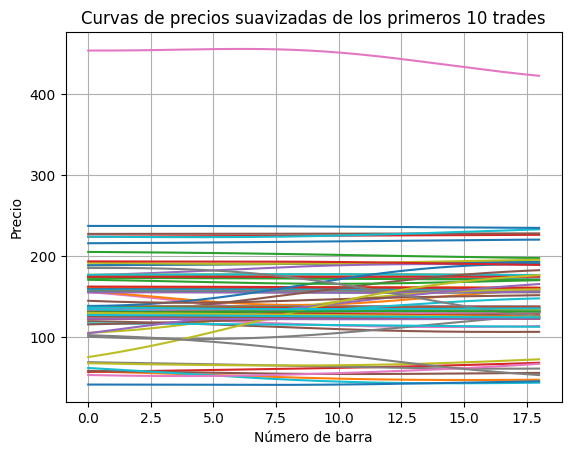

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
fd_smooth[:100].plot()  # primeras 10 curvas
plt.xlabel("Número de barra")
plt.ylabel("Precio")
plt.title("Curvas de precios suavizadas de los primeros 10 trades")
plt.grid(True)
plt.show()

In [39]:
%pip install deap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\anruk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## TRADES

In [46]:
df_completo

,productname,prox_open_hour,prox_close_hour,n_filas,precio_open,precio_close,profit_percentage,trade_length
0,EFKyf,2020-06-03 17:00:00,2020-07-08 09:00:00,149,215.44,222.51,0.032817,34.725694
1,lVhDF,2020-06-03 17:00:00,2020-12-23 06:00:00,868,157.19,144.18,-0.082766,202.574306
2,RsCCj,2020-06-03 17:00:00,2020-07-23 17:00:00,217,207.65,188.86,-0.090489,49.934722
3,yqSyy,2020-06-04 17:00:00,2021-03-05 18:00:00,1165,201.27,210.92,0.047946,274.112500
4,MeTxk,2020-06-11 21:00:00,2020-07-29 13:00:00,203,134.00,136.23,0.016642,47.548611
...,...,...,...,...,...,...,...,...
2540,AmsD8,2024-12-19 14:00:00,2024-12-20 14:00:00,7,148.50,148.61,0.000741,0.999306
2541,UCc87,2024-12-19 14:00:00,2024-12-20 14:00:00,7,86.50,86.35,-0.001734,0.999306
2542,AmsD8,2024-12-24 14:00:00,2024-12-30 14:00:00,19,149.32,149.14,-0.001205,5.999306
2543,2Zc0n,2024-12-24 14:00:00,2024-12-26 14:00:00,7,129.45,129.27,-0.001390,1.999306


## DF Completo

In [50]:
import random
import numpy as np
import pandas as pd

from deap import base, creator, tools, algorithms

# ==============================
# CONFIGURACIÓN GENERAL
# ==============================
CAPITAL_INICIAL = 100
N_GENERACIONES = 50
TAM_POBLACION = 10
PROB_CRUCE = 0.5
PROB_MUTACION = 0.2

# ==============================
# CREACIÓN FITNESS
# ==============================
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# ==============================
# DEFINICIÓN DE GENES
# ==============================

# Entrada
toolbox.register("min_filas", random.randint, 10, 500)
toolbox.register("min_dias", random.randint, 1, 200)

# Salida
toolbox.register("take_profit", random.uniform, 0.01, 0.30)
toolbox.register("stop_loss", random.uniform, 0.01, 0.30)
toolbox.register("max_dias", random.randint, 5, 300)

# Tamaño posición
toolbox.register("capital_pct", random.uniform, 0.01, 0.30)

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    (
        toolbox.min_filas,
        toolbox.min_dias,
        toolbox.take_profit,
        toolbox.stop_loss,
        toolbox.max_dias,
        toolbox.capital_pct,
    ),
    n=1,
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# ==============================
# REGLAS DE TRADING
# ==============================

def entrar(fila, min_filas, min_dias):
    return (
        fila["n_filas"] >= min_filas
        and fila["trade_length"] >= min_dias
    )


def salir(fila, take_profit, stop_loss, max_dias):
    if fila["profit_percentage"] >= take_profit:
        return True
    if fila["profit_percentage"] <= -stop_loss:
        return True
    if fila["trade_length"] >= max_dias:
        return True
    return False

def limitar(ind):
    ind[0] = int(max(10, min(500, ind[0])))     # min_filas
    ind[1] = int(max(1, min(200, ind[1])))      # min_dias
    ind[2] = max(0.001, min(0.30, ind[2]))      # take_profit
    ind[3] = max(0.001, min(0.30, ind[3]))      # stop_loss
    ind[4] = int(max(5, min(300, ind[4])))      # max_dias
    ind[5] = max(0.01, min(0.30, ind[5]))       # capital_pct
    return ind

# ==============================
# BACKTEST
# ==============================

def backtest(individuo, df):
    min_filas, min_dias, tp, sl, max_dias, cap_pct = individuo
    capital = CAPITAL_INICIAL
    capital_max = CAPITAL_INICIAL
    drawdown_max = 0

    for _, fila in df.iterrows():

        if not entrar(fila, min_filas, min_dias):
            continue

        if salir(fila, tp, sl, max_dias):
            capital *= (1 + fila["profit_percentage"] * cap_pct)

            # drawdown
            capital_max = max(capital_max, capital)
            drawdown = (capital_max - capital) / capital_max
            drawdown_max = max(drawdown_max, drawdown)

    # penalización por riesgo
    fitness = capital - drawdown_max * 5000
    return (fitness,)


# ==============================
# EVALUACIÓN GENÉTICA
# ==============================

toolbox.register("evaluate", backtest, df=df_completo)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.2)

def mate_y_limitar(ind1, ind2):
    tools.cxBlend(ind1, ind2, alpha=0.5)
    limitar(ind1)
    limitar(ind2)
    return ind1, ind2

def mutar_y_limitar(ind):
    tools.mutGaussian(ind, mu=0, sigma=5, indpb=0.2)
    limitar(ind)
    return (ind,)

toolbox.register("mate", mate_y_limitar)
toolbox.register("mutate", mutar_y_limitar)

toolbox.register("select", tools.selTournament, tournsize=3)

# ==============================
# EJECUCIÓN
# ==============================

def ejecutar_genetico():
    poblacion = toolbox.population(n=TAM_POBLACION)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", np.max)
    stats.register("avg", np.mean)

    poblacion, log = algorithms.eaSimple(
        poblacion,
        toolbox,
        cxpb=PROB_CRUCE,
        mutpb=PROB_MUTACION,
        ngen=N_GENERACIONES,
        stats=stats,
        verbose=True,
    )

    mejor = tools.selBest(poblacion, k=1)[0]
    return mejor


# ==============================
# EJECUTAR
# ==============================

mejor_estrategia = ejecutar_genetico()

print("\nMEJOR ESTRATEGIA ENCONTRADA:")
print(f"min_filas     : {mejor_estrategia[0]}")
print(f"min_dias      : {mejor_estrategia[1]}")
print(f"take_profit   : {mejor_estrategia[2]:.3f}")
print(f"stop_loss     : {mejor_estrategia[3]:.3f}")
print(f"max_dias      : {mejor_estrategia[4]}")
print(f"capital_pct   : {mejor_estrategia[5]:.2f}")


gen	nevals	max    	avg     
0  	10    	73.4159	-1446.82
1  	8     	84.3017	-490.194
2  	6     	84.3017	40.9768 
3  	6     	85.7983	80.0762 
4  	9     	84.6582	74.5691 
5  	2     	84.3953	83.4179 
6  	8     	84.3953	40.4408 
7  	4     	84.6582	84.3841 
8  	9     	84.8831	84.0458 
9  	4     	84.8831	84.761  
10 	7     	92.1974	85.6145 
11 	8     	93.4975	86.3312 
12 	2     	93.4975	88.1406 
13 	8     	97.3793	82.8451 
14 	5     	148.365	79.3433 
15 	5     	148.365	-291.365
16 	6     	148.365	112.277 
17 	8     	215.565	123.342 
18 	5     	227.562	-222.513
19 	5     	239.612	210.638 
20 	4     	239.612	231.183 
21 	4     	239.612	238.407 
22 	6     	304.239	231.817 
23 	6     	304.239	182.354 
24 	6     	304.239	-128.265
25 	9     	583.506	249.858 
26 	7     	693.873	38.8124 
27 	8     	693.873	540.52  
28 	7     	794.073	672.947 
29 	3     	1001.58	702.613 
30 	7     	1265.87	890.865 
31 	8     	1298.17	1012.76 
32 	4     	1298.17	1053.08 
33 	6     	1376.77	1007.89 
34 	4     	1376.77	5

## DF Algoritmos

In [51]:
df_algoritmos

,Date,fpJbh,HcI9f,QEwOm,EFKyf,lVhDF,RsCCj,LYP1Q,yqSyy,MeTxk,...,INaLS,V7Lrn,KLCQs,eLk6n,IfdDD,uPX0V,fS7OL,bpN6K,eACAc,AmsD8
0,2020-06-01 01:00:00,0.00,0.00,0.0,214.49,0.00,207.11,0.00,0.0,133.75,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
1,2020-06-01 05:00:00,0.00,189.54,0.0,214.90,0.00,207.17,0.00,0.0,133.75,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
2,2020-06-01 09:00:00,0.00,189.55,0.0,214.29,0.00,207.20,0.00,0.0,133.79,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
3,2020-06-01 13:00:00,0.00,189.61,0.0,214.21,0.00,207.05,0.00,0.0,133.77,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
4,2020-06-01 17:00:00,0.00,0.00,0.0,214.83,0.00,207.15,0.00,0.0,133.60,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7141,2024-12-30 06:00:00,0.00,0.00,0.0,323.75,0.00,0.00,0.00,0.0,0.00,...,135.27,0.00,129.85,0.00,0.00,0.0,120.78,120.90,130.78,149.14
7142,2024-12-30 10:00:00,0.00,0.00,0.0,323.85,0.00,0.00,0.00,0.0,0.00,...,135.25,0.00,129.86,0.00,0.00,0.0,121.06,120.93,130.70,149.14
7143,2024-12-30 14:00:00,0.00,0.00,0.0,325.84,0.00,0.00,0.00,0.0,0.00,...,135.35,0.00,129.88,0.00,0.00,0.0,120.86,120.76,129.50,149.14
7144,2024-12-30 18:00:00,70.88,0.00,0.0,324.54,151.71,0.00,921.85,0.0,0.00,...,135.60,124.61,130.20,136.09,213.22,0.0,121.11,120.88,130.64,148.48


In [ ]:
df_algoritmos = pd.DataFrame()
df_algoritmos['Date'] = horas
for algo in algs_benchmark:
    name = os.path.splitext(os.path.basename(algo))[0]

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'])

    df_merge = (
        df[['plot_date', 'open']]
        .rename(columns={'open': name})
    )

    df_algoritmos = df_algoritmos.merge(
        df_merge,
        how='left',
        left_on='Date',
        right_on='plot_date'
    ).drop(columns='plot_date')

df_algoritmos.fillna(0, inplace=True)

### Opción 1

In [80]:
import numpy as np
import pandas as pd

# -----------------------------
# Parámetros
# -----------------------------
Q = 0.5           # factor de riesgo
MAX_ACTIVOS = 5   # máximo 5 activos por fecha
VENTANA = 20      # ventana rolling para calcular retornos
EPSILON = 1e-8    # evita división por cero

# df_algoritmos ya debe estar cargado
# Aseguramos que 0 se interprete como "sin dato"
df_prices = df_algoritmos.set_index("Date").replace(0, np.nan)

# Diccionario para guardar resultados
carteras = {}

# Fechas del histórico
fechas = df_prices.index

# -----------------------------
# Loop sobre fechas
# -----------------------------
for fecha in fechas:
    # Activos disponibles hasta esta fecha
    
    df_disponible = df_prices.loc[:fecha].dropna(axis=1, how='all')
    
    activos = df_disponible.columns
    n = len(activos)
    
    if n == 0:
        carteras[fecha] = []
        continue

    # Calculamos retornos de la ventana más reciente
    returns = df_disponible[activos].pct_change(fill_method=None).dropna(how='all')
    returns = returns.tail(VENTANA)

    # Evitar warnings si hay muy pocos datos
    if returns.shape[0] < 2:
        carteras[fecha] = []
        continue

    # Retornos esperados y matriz de covarianza
    mu = returns.mean(skipna=True).values
    cov = returns.cov().values

    # Evitar covariancias con NaN
    cov = np.nan_to_num(cov, nan=0.0)

    # Riesgo individual (diagonal)
    riesgo_ind = np.diag(cov)

    # Score para selección: mu - Q*riesgo
    score = mu - Q * riesgo_ind

    # Evitar división por cero si usaras mu/risgo_ind
    # score = mu / (riesgo_ind + EPSILON)

    # Orden descendente
    indices_orden = np.argsort(score)[::-1]

    # Seleccionamos hasta MAX_ACTIVOS
    seleccionados = [activos[i] for i in indices_orden[:min(MAX_ACTIVOS, n)]]

    carteras[fecha] = seleccionados

# Convertimos a DataFrame
df_carteras = pd.DataFrame(list(carteras.items()), columns=['Date', 'Activos'])

# Mostrar primeras 20 fechas
print(df_carteras.head(20))


                  Date                              Activos
0  2020-06-01 01:00:00                                   []
1  2020-06-01 05:00:00                                   []
2  2020-06-01 09:00:00  [Mvijr, ynUj1, Zouwi, Ev5zR, kjfaW]
3  2020-06-01 13:00:00  [Zouwi, ke3ev, c0dJa, IWj4m, G1SiC]
4  2020-06-01 17:00:00  [IZexz, Zouwi, G1SiC, pb2zU, rKjYg]
5  2020-06-01 21:00:00  [IfdDD, yFp3w, lVdo5, 0m0In, pos3v]
6  2020-06-02 01:00:00  [IfdDD, yqSyy, 0m0In, lVdo5, pos3v]
7  2020-06-02 05:00:00  [IfdDD, yFp3w, aX1A3, pos3v, 1uL6a]
8  2020-06-02 09:00:00  [IfdDD, yFp3w, aX1A3, pos3v, wSG9M]
9  2020-06-02 13:00:00  [IfdDD, aX1A3, wSG9M, 2EnQY, KMbKa]
10 2020-06-02 17:00:00  [IfdDD, yFp3w, aX1A3, wSG9M, 2EnQY]
11 2020-06-02 21:00:00  [IfdDD, yFp3w, 2EnQY, 9YYu5, WP8P8]
12 2020-06-03 01:00:00  [IfdDD, yFp3w, H0r8b, Mt0w3, 2EnQY]
13 2020-06-03 05:00:00  [IfdDD, q4aE1, nibNX, yFp3w, H0r8b]
14 2020-06-03 09:00:00  [IfdDD, H0r8b, yFp3w, Mt0w3, 2EnQY]
15 2020-06-03 13:00:00  [IfdDD, H0r8b, y

In [73]:
df_carteras.tail()

,Date,Activos
7141,2024-12-30 06:00:00,"[3CQHn, ftSR7, sE0hK, q4aE1, Mvijr]"
7142,2024-12-30 10:00:00,"[3CQHn, vDodF, q4aE1, GkFcy, ftSR7]"
7143,2024-12-30 14:00:00,"[3CQHn, vDodF, ftSR7, sE0hK, 61tRv]"
7144,2024-12-30 18:00:00,"[Mvijr, 3CQHn, q4aE1, GkFcy, CkEpy]"
7145,2024-12-30 22:00:00,"[q4aE1, sE0hK, GkFcy, Mvijr, CkEpy]"


In [69]:
len(mu)

132

### Opción 1.2

In [128]:
df_algoritmos = pd.DataFrame()
df_algoritmos['Date'] = horas
for algo in algs_benchmark:
    name = os.path.splitext(os.path.basename(algo))[0]

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'])

    df_merge = (
        df[['plot_date', 'open']]
        .rename(columns={'open': name})
    )

    df_algoritmos = df_algoritmos.merge(
        df_merge,
        how='left',
        left_on='Date',
        right_on='plot_date'
    ).drop(columns='plot_date')

df_algoritmos.fillna(0, inplace=True)

In [134]:
import numpy as np
import pandas as pd

# -----------------------------
# Parámetros
# -----------------------------
Q = 0.5
MAX_ACTIVOS = 5
VENTANA = 20

# -----------------------------
# Datos
# -----------------------------
# 0 = sin dato → NaN
df_prices = df_algoritmos.set_index("Date").replace(0, np.nan)
fechas = df_prices.index

# -----------------------------
# Estructuras
# -----------------------------
carteras = {}            # activos seleccionados
capital_por_activo = {}  # {activo: capital}
valor_total = {}         # capital total
pesos_debug = {}         # lista de capitales por activo (debug)

capital_total = 1.0      # empezamos con 100%

# -----------------------------
# Loop principal
# -----------------------------
for i in range(len(fechas) - 1):
    fecha = fechas[i]
    fecha_sig = fechas[i + 1]

    # Inicializar estructuras
    carteras[fecha] = []
    pesos_debug[fecha] = []

    # -----------------------------
    # Selección de activos
    # -----------------------------
    df_disponible = df_prices.loc[:fecha].dropna(axis=1, how="all")
    activos = df_disponible.columns
    n = len(activos)

    if n == 0:
        continue

    returns = df_disponible[activos].pct_change(fill_method=None).dropna(how="all")
    returns = returns.tail(VENTANA)

    if returns.shape[0] < 2:
        continue

    mu = returns.mean(skipna=True).values
    cov = np.nan_to_num(returns.cov().values, nan=0.0)
    riesgo = np.diag(cov)

    score = mu - Q * riesgo
    indices = np.argsort(score)[::-1]
    seleccionados = [activos[i] for i in indices[:min(MAX_ACTIVOS, n)]]

    carteras[fecha] = seleccionados

    # -----------------------------
    # Primera inversión (20% cada uno)
    # -----------------------------
    if not capital_por_activo and seleccionados:
        peso = capital_total / len(seleccionados)
        capital_por_activo = {a: peso for a in seleccionados}
        valor_total[fecha] = capital_total
        pesos_debug[fecha] = [peso] * len(seleccionados)
        continue

    # -----------------------------
    # Actualizar capital de activos que continúan
    # -----------------------------
    nuevos_capitales = {}

    for activo, cap in capital_por_activo.items():
        if activo in seleccionados:
            p0 = df_prices.loc[fecha, activo]
            p1 = df_prices.loc[fecha_sig, activo]

            # si no hay precio → mantener capital
            if pd.isna(p0) or pd.isna(p1):
                nuevos_capitales[activo] = cap
            else:
                nuevos_capitales[activo] = cap * (p1 / p0)

    # -----------------------------
    # Capital liberado por ventas
    # -----------------------------
    capital_libre = capital_total - sum(nuevos_capitales.values())

    # -----------------------------
    # Comprar activos nuevos (heredan capital)
    # -----------------------------
    nuevos = [a for a in seleccionados if a not in nuevos_capitales]

    if nuevos:
        reparto = capital_libre / len(nuevos)
        for a in nuevos:
            nuevos_capitales[a] = reparto

    # -----------------------------
    # Actualizar estado
    # -----------------------------
    capital_por_activo = nuevos_capitales
    capital_total = sum(capital_por_activo.values())

    # 🔑 Guardamos capital en la fecha siguiente, y pesos alineados con la cartera seleccionada
    valor_total[fecha_sig] = capital_total
    pesos_debug[fecha_sig] = [capital_por_activo.get(a, 0) for a in seleccionados]

# -----------------------------
# DataFrame final
# -----------------------------
df_carteras = pd.DataFrame({
    "Date": list(valor_total.keys()),
    "Activos": [carteras.get(f, []) for f in valor_total.keys()],
    "% Invertido": [valor_total[f] for f in valor_total.keys()],
    "% por Activo": [pesos_debug.get(f, []) for f in valor_total.keys()]
})

df_carteras["Retorno"] = df_carteras["% Invertido"].pct_change().fillna(0)

print(df_carteras.head(20))


                  Date                              Activos  % Invertido  \
0  2020-06-01 09:00:00  [Mvijr, ynUj1, Zouwi, Ev5zR, kjfaW]     1.000000   
1  2020-06-01 17:00:00  [IZexz, Zouwi, G1SiC, pb2zU, rKjYg]     1.000000   
2  2020-06-01 21:00:00  [IfdDD, yFp3w, lVdo5, 0m0In, pos3v]     1.000000   
3  2020-06-02 01:00:00  [IfdDD, yqSyy, 0m0In, lVdo5, pos3v]     1.000000   
4  2020-06-02 05:00:00  [IfdDD, yFp3w, aX1A3, pos3v, 1uL6a]     1.000000   
5  2020-06-02 09:00:00  [IfdDD, yFp3w, aX1A3, pos3v, wSG9M]     1.000000   
6  2020-06-02 13:00:00  [IfdDD, aX1A3, wSG9M, 2EnQY, KMbKa]     1.000000   
7  2020-06-02 17:00:00  [IfdDD, yFp3w, aX1A3, wSG9M, 2EnQY]     1.000000   
8  2020-06-02 21:00:00  [IfdDD, yFp3w, 2EnQY, 9YYu5, WP8P8]     1.000000   
9  2020-06-03 01:00:00  [IfdDD, yFp3w, H0r8b, Mt0w3, 2EnQY]     1.000000   
10 2020-06-03 05:00:00  [IfdDD, q4aE1, nibNX, yFp3w, H0r8b]     1.000000   
11 2020-06-03 09:00:00  [IfdDD, H0r8b, yFp3w, Mt0w3, 2EnQY]     1.000000   
12 2020-06-0

In [137]:
df_carteras.tail(15)

,Date,Activos,% Invertido,% por Activo,Retorno
7128,2024-12-26 14:00:00,"[Mvijr, vDodF, 6K07g, CkEpy, GkFcy]",0.957645,[],0.0
7129,2024-12-26 18:00:00,"[vDodF, 61tRv, CkEpy, GkFcy, q4aE1]",0.957645,[],0.0
7130,2024-12-26 22:00:00,"[CkEpy, ftSR7, Mvijr, 61tRv, 6K07g]",0.957645,[],0.0
7131,2024-12-27 02:00:00,"[GkFcy, q4aE1, 3CQHn, ftSR7, sE0hK]",0.957645,[],0.0
7132,2024-12-27 06:00:00,"[kfqHw, aX1A3, UQILX, rKjYg, uPX0V]",0.957645,[],0.0
7133,2024-12-27 10:00:00,"[6K07g, k5ecp, KMbKa, MkRxS, uPX0V]",0.957645,[],0.0
7134,2024-12-27 14:00:00,"[UQILX, aX1A3, 5r1Rh, KMbKa, uPX0V]",0.957645,[],0.0
7135,2024-12-27 18:00:00,"[u9WP3, WTetH, 63EZx, 6BB3r, uPX0V]",0.957645,[],0.0
7136,2024-12-29 22:00:00,"[vDodF, ftSR7, Mvijr, 61tRv, 3CQHn]",0.957645,[],0.0
7137,2024-12-30 02:00:00,"[3CQHn, ftSR7, sE0hK, 61tRv, Mvijr]",0.957645,[],0.0
